In [90]:
import os
from pathlib import Path
import pandas as pd
import glob
import cv2
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, recall_score, precision_score
import seaborn as sns
import matplotlib.pyplot as plt

In [91]:
dataset_path = Path("Dataset")

dados = []

for class_folder in dataset_path.iterdir():
    if class_folder.is_dir():
        classe = class_folder.stem
        for img_path in class_folder.glob("*.[pj][pn]g"):  # jpg, jpeg, png
            img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue  # caso erro ao ler a imagem

            _, img_bin = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

            moments = cv2.moments(img_bin)
            huMoments = cv2.HuMoments(moments).flatten()

            huMoments = [-np.sign(h) * np.log10(abs(h)) if h != 0 else 0 for h in huMoments]

            dados.append({
                "caminho": str(img_path),
                "classe": classe.split("_")[0],
                **{f"hu{i+1}": hu for i, hu in enumerate(huMoments)}
            })

df_hu = pd.DataFrame(dados)

In [92]:
df_hu

,caminho,classe,hu1,hu2,hu3,hu4,hu5,hu6,hu7
0,Dataset\1_circle\10.png,1,2.992754,11.883470,16.697893,14.581054,30.948229,21.180396,30.228274
1,Dataset\1_circle\100.png,1,2.994143,12.149593,16.147831,13.742612,29.208994,-20.243916,28.708484
2,Dataset\1_circle\1002.png,1,2.927618,10.490698,15.590934,14.019846,-29.529052,19.407398,-28.833900
3,Dataset\1_circle\1005.png,1,2.922419,10.611498,16.430575,13.602133,28.804408,18.914947,-28.738568
4,Dataset\1_circle\1006.png,1,2.925540,10.678662,17.028920,13.697260,-29.064856,-19.534620,29.904028
...,...,...,...,...,...,...,...,...,...
3995,Dataset\4_triangle\983.png,4,3.045981,10.795856,13.103313,11.608480,-24.014298,-17.006440,-24.308094
3996,Dataset\4_triangle\987.png,4,3.044395,10.289727,13.283033,11.544359,24.655835,-16.741659,-23.966969
3997,Dataset\4_triangle\988.png,4,3.043056,10.137152,13.343135,11.509446,24.235099,-16.630531,-23.998764
3998,Dataset\4_triangle\994.png,4,3.044746,10.482388,13.073759,11.881134,24.529765,-17.214521,24.490223


In [93]:
X = df_hu.iloc[:, 2:-1]
y = df_hu.iloc[:, 1]

## Teste 60/40

In [94]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=100)

In [95]:
knn = KNeighborsClassifier()
sc = StandardScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [96]:
param_grid = {
    "n_neighbors": [1, 3, 5, 7, 9, 11],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan", "minkowski"]
}

grid = GridSearchCV(knn, param_grid, cv=3, scoring="accuracy", n_jobs=-1)
grid.fit(X_train, y_train)

y_pred = grid.best_estimator_.predict(X_test)
print("\nAcurácia no teste:", accuracy_score(y_test, y_pred))
print("\nRecall no teste:", recall_score(y_test, y_pred,average="macro"))
print("\nPrecisão no teste:", precision_score(y_test, y_pred, average="macro"))
print("\nRelatório de classificação:\n", classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


Acurácia no teste: 0.970625

Recall no teste: 0.9712052140465846

Precisão no teste: 0.9718768977958776

Relatório de classificação:
               precision    recall  f1-score   support

           1       0.93      0.96      0.94       417
           2       0.96      0.92      0.94       404
           3       1.00      1.00      1.00       391
           4       1.00      1.00      1.00       388

    accuracy                           0.97      1600
   macro avg       0.97      0.97      0.97      1600
weighted avg       0.97      0.97      0.97      1600

[[402  15   0   0]
 [ 32 372   0   0]
 [  0   0 391   0]
 [  0   0   0 388]]


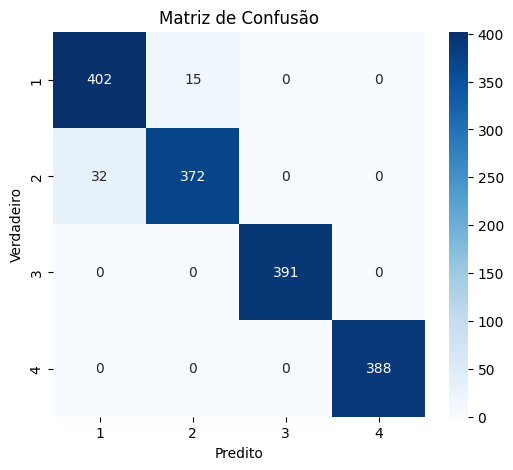

In [97]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=np.unique(y_test),
            yticklabels=np.unique(y_test))

plt.xlabel("Predito")
plt.ylabel("Verdadeiro")
plt.title("Matriz de Confusão")
plt.savefig("./6040_split")
plt.show()

## 600 primeiras imagens treino 

In [98]:
df_train = df_hu.groupby("classe").sample(n=150, random_state=42)
df_test = df_hu.drop(df_train.index)

In [99]:
df_train

,caminho,classe,hu1,hu2,hu3,hu4,hu5,hu6,hu7
521,Dataset\1_circle\269.png,1,2.927896,11.070430,15.665771,13.996763,28.886045,-19.916263,29.142996
737,Dataset\1_circle\32.png,1,2.994248,12.048244,16.487625,14.601330,-30.232085,20.746604,-30.387948
740,Dataset\1_circle\3206.png,1,2.944246,10.388753,15.711412,13.620085,-28.295627,-18.885550,28.963620
660,Dataset\1_circle\3034.png,1,2.992833,11.397988,16.830169,14.499416,-30.690666,20.201113,30.184338
411,Dataset\1_circle\2411.png,1,2.994098,10.842162,17.119143,14.586031,-30.524933,-20.203838,30.680679
...,...,...,...,...,...,...,...,...,...
3490,Dataset\4_triangle\2684.png,4,3.053969,10.450532,13.381970,11.998517,24.692736,-17.446937,-25.559436
3186,Dataset\4_triangle\1630.png,4,3.046706,10.680679,13.111069,11.836763,-24.586935,-17.178753,24.382076
3043,Dataset\4_triangle\1114.png,4,3.040938,10.274076,13.167713,11.629035,-26.466475,-16.788761,24.027412
3715,Dataset\4_triangle\3441.png,4,3.048223,10.271044,13.278841,11.670748,24.464034,-16.806483,24.202490


In [100]:
X_train = df_train.iloc[:, 2:-1]
y_train = df_train.iloc[:, 1]

X_test = df_test.iloc[:, 2:-1]
y_test = df_test.iloc[:, 1]

In [101]:
knn = KNeighborsClassifier()
sc = StandardScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [102]:
param_grid = {
    "n_neighbors": [1, 3, 5, 7, 9, 11],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan", "minkowski"]
}

grid = GridSearchCV(knn, param_grid, cv=3, scoring="accuracy", n_jobs=-1)
grid.fit(X_train, y_train)

y_pred = grid.best_estimator_.predict(X_test)
print("\nAcurácia no teste:", accuracy_score(y_test, y_pred))
print("\nRecall no teste:", recall_score(y_test, y_pred,average="macro"))
print("\nPrecisão no teste:", precision_score(y_test, y_pred, average="macro"))
print("\nRelatório de classificação:\n", classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


Acurácia no teste: 0.9461764705882353

Recall no teste: 0.9461764705882353

Precisão no teste: 0.9465390896467816

Relatório de classificação:
               precision    recall  f1-score   support

           1       0.91      0.88      0.89       850
           2       0.88      0.91      0.89       850
           3       1.00      1.00      1.00       850
           4       1.00      1.00      1.00       850

    accuracy                           0.95      3400
   macro avg       0.95      0.95      0.95      3400
weighted avg       0.95      0.95      0.95      3400

[[745 105   0   0]
 [ 74 775   1   0]
 [  0   3 847   0]
 [  0   0   0 850]]


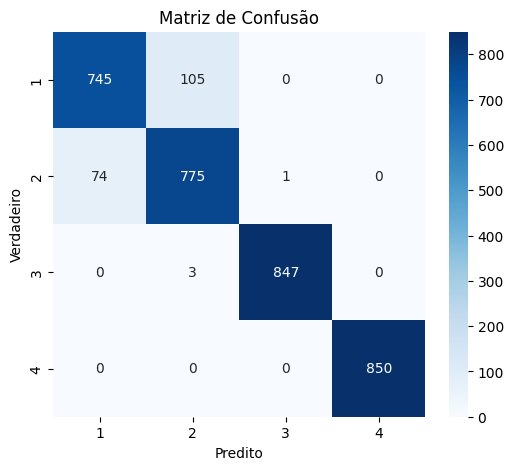

In [103]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=np.unique(y_test),
            yticklabels=np.unique(y_test))

plt.xlabel("Predito")
plt.ylabel("Verdadeiro")
plt.title("Matriz de Confusão")
plt.savefig("./600_teste")
plt.show()